In [1]:
from models.nsf import SplineFlowSummary
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.amp import GradScaler
import numpy as np

In [2]:
from sklearn.decomposition import PCA

def fit_com_pca(dataset_com, theta_dim=8):
    all_com = np.stack(dataset_com)            # (N, T, 3)
    N, T, D = all_com.shape
    all_com_flat = all_com.reshape(N, T * D)

    pca = PCA(n_components=theta_dim)
    theta_all = pca.fit_transform(all_com_flat)

    theta_mean = theta_all.mean(axis=0)
    theta_std = theta_all.std(axis=0) + 1e-8

    return pca, theta_mean, theta_std

In [3]:
from torch.utils.data import Dataset

class FootComDataset(Dataset):
    def __init__(self, dataset_foot, dataset_com, pca, theta_mean=None, theta_std=None):
        self.dataset_foot = dataset_foot
        self.dataset_com = dataset_com
        self.pca = pca
        self.theta_mean = theta_mean
        self.theta_std = theta_std

    def __len__(self):
        return len(self.dataset_foot)

    def __getitem__(self, idx):
        foot = self.dataset_foot[idx]   # (T, foot_dim)
        com = self.dataset_com[idx]     # (T, 3)

        x = foot.reshape(-1).astype(np.float32)

        theta = self.pca.transform(com.reshape(1, -1))[0].astype(np.float32)

        if self.theta_mean is not None and self.theta_std is not None:
            theta = (theta - self.theta_mean) / self.theta_std

        return torch.tensor(x, dtype=torch.float32), torch.tensor(theta, dtype=torch.float32)

In [6]:
import numpy as np
#doesnt work well, due to the mix between treadmill and overground data, which have different drift patterns. Switch to better normalization method.
def normalize_sequence(foot, com):
    """
    Transform a full trajectory into a consistent local frame.

    Args:
        foot: (T, 6)  [rx, ry, rz, lx, ly, lz]
        com:  (T, 3)

    Returns:
        foot_rel: (T, 6)
        com_rel:  (T, 3)
    """

    foot = foot.copy()
    com = com.copy()
    T = len(com)

    # initial reference (midpoint between feet at t=0)
    mid0 = (foot[0, :3] + foot[0, 3:]) / 2  # (3,)

    # subtract global translation
    foot[:, :3] -= mid0
    foot[:, 3:] -= mid0
    com -= mid0

    #remove forward drift (if not on a treadmill)
    t= np.arange(T)
    foot_mid = (foot[:, :3] + foot[:, 3:]) / 2
    vx = (foot_mid[-1, 0] - foot_mid[0, 0]) / (T - 1)
    drift_x = t * vx
    com[:, 0]      -= drift_x
    foot[:, 0]     -= drift_x
    foot[:, 3]     -= drift_x

    # remove small bias (dataset mismatch correction)
    com -= com.mean(axis=0)

    return foot.astype(np.float32), com.astype(np.float32)

In [4]:
def normalize_sequence_2(foot, com):
    foot = foot.copy()
    com = com.copy()
    
    # Instantaneous midpoint between feet at every timestep
    foot_mid = (foot[:, :3] + foot[:, 3:]) / 2  # (T, 3)
    
    # Express foot and CoM positions relative to this midpoint
    foot[:, :3] -= foot_mid
    foot[:, 3:] -= foot_mid
    com -= foot_mid  # CoM relative to foot midpoint at each t
    
    # Remove mean to center (handles any residual bias)
    com -= com.mean(axis=0)
    foot[:, :3] -= foot[:, :3].mean(axis=0)
    foot[:, 3:] -= foot[:, 3:].mean(axis=0)
    
    return foot.astype(np.float32), com.astype(np.float32)

In [5]:
def compute_tail_bound(dataset, quantile=0.9999, margin=1.2):
    """
    Compute tail_bound from actual PCA-projected, standardized theta values.
    
    quantile: cover this fraction of training data (e.g. 0.9999 = 4-sigma equiv)
    margin:   safety multiplier on top
    """
    thetas = []
    for i in range(len(dataset)):
        _, theta = dataset[i]
        thetas.append(theta.numpy())
    
    thetas = np.stack(thetas)          # (N, theta_dim)
    max_abs = np.abs(thetas).max(axis=1)   # worst dimension per sample
    tail_bound = float(np.quantile(max_abs, quantile)) * margin
    
    print(f"  theta abs-max:  mean={max_abs.mean():.3f}, "
          f"p99={np.quantile(max_abs,0.99):.3f}, "
          f"p99.99={np.quantile(max_abs,0.9999):.3f}")
    print(f"  → tail_bound = {tail_bound:.3f}")
    return round(tail_bound, 1)

In [6]:
data = np.load("dataset.npz")
print(data)

#they are not relative to foot coordinates, we have some bodies moving forward, others on a threadmill, so we need to normalize them into a consistent local frame before PCA
foot = data["foot"].astype(np.float32)  # (N, T, 6)
com  = data["com"].astype(np.float32)   # (N, T, 3)
height = data["height"].astype(np.float32)  # (N, 1)    

NpzFile 'dataset.npz' with keys: foot, com, height


In [7]:
foot_norm = []
com_norm = []
for f, c in zip(foot, com):
    f_n, c_n = normalize_sequence_2(f, c)
    foot_norm.append(f_n)
    com_norm.append(c_n)
foot_norm = np.array(foot_norm)  # (N, T, 6)
com_norm = np.array(com_norm)  # (N, T, 3)

In [6]:
print(foot_norm.shape, com_norm.shape)

(100000, 39, 6) (100000, 39, 3)


In [11]:
print("Shape:", com_norm.shape)
print("Min:", com_norm.min())
print("Max:", com_norm.max())
print("Mean:", com_norm.mean())
print("Std:", com_norm.std())
std_across_samples = com_norm.std(axis=0)   # (T, 3)
print("Mean std over time:", std_across_samples.mean())

Shape: (100000, 39, 3)
Min: -0.34293932
Max: 0.17824326
Mean: -1.26035805e-11
Std: 0.04356275
Mean std over time: 0.029986814


In [8]:
from sklearn.model_selection import train_test_split

foot_train, foot_test, com_train, com_test = train_test_split(
    foot_norm,
    com_norm,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

In [9]:
DIM_PCA_COM = 10
pca, theta_mean, theta_std = fit_com_pca(com_train, theta_dim=DIM_PCA_COM)

In [10]:
train_dataset = FootComDataset(
    dataset_foot=foot_train,
    dataset_com=com_train,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
)

In [11]:
test_dataset = FootComDataset(
    dataset_foot=foot_test,
    dataset_com=com_test,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
)

In [17]:
import matplotlib.pyplot as plt

def find_outliers(dataset, clip_sigma=4.0):
    outlier_indices = []
    outlier_info = []
    
    for i in range(len(dataset)):
        _, theta = dataset[i]
        theta_np = theta.numpy()
        
        max_abs = np.abs(theta_np).max()
        worst_dim = np.abs(theta_np).argmax()
        
        if max_abs > clip_sigma:
            outlier_indices.append(i)
            outlier_info.append({
                'idx': i,
                'max_abs': max_abs,
                'worst_dim': worst_dim,
                'theta_std': theta_np
            })
    
    return outlier_indices, outlier_info

# Then plot the actual foot + CoM trajectories for outlier indices
def plot_outlier_sequence(foot, com, idx):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    fig.suptitle(f"Sample {idx}")
    for j, label in enumerate(['x', 'y', 'z']):
        axes[0, j].plot(com[:, j])
        axes[0, j].set_title(f"CoM {label}")
        axes[1, j].plot(foot[:, j], label='right')
        axes[1, j].plot(foot[:, j+3], label='left')
        axes[1, j].set_title(f"Foot {label}")
        axes[1, j].legend()
    plt.tight_layout()
    plt.show()

In [19]:
out_indices, out_info = find_outliers(train_dataset, clip_sigma=4.0)
print(f"Found {len(out_indices)} outliers in training set with clip_sigma=4.0")

Found 40 outliers in training set with clip_sigma=4.0


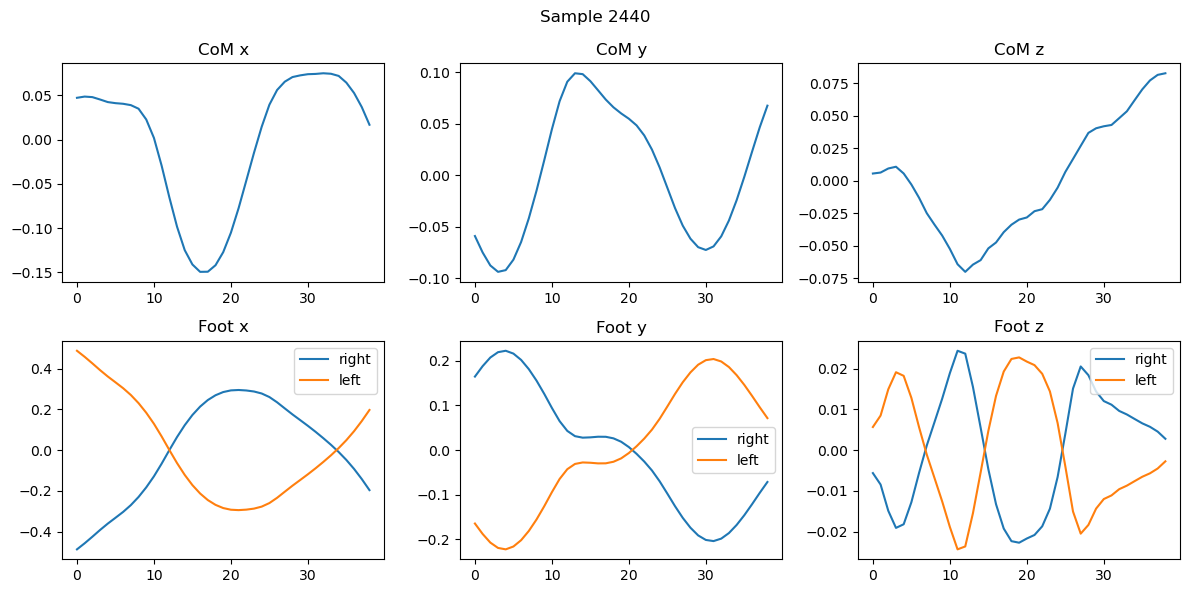

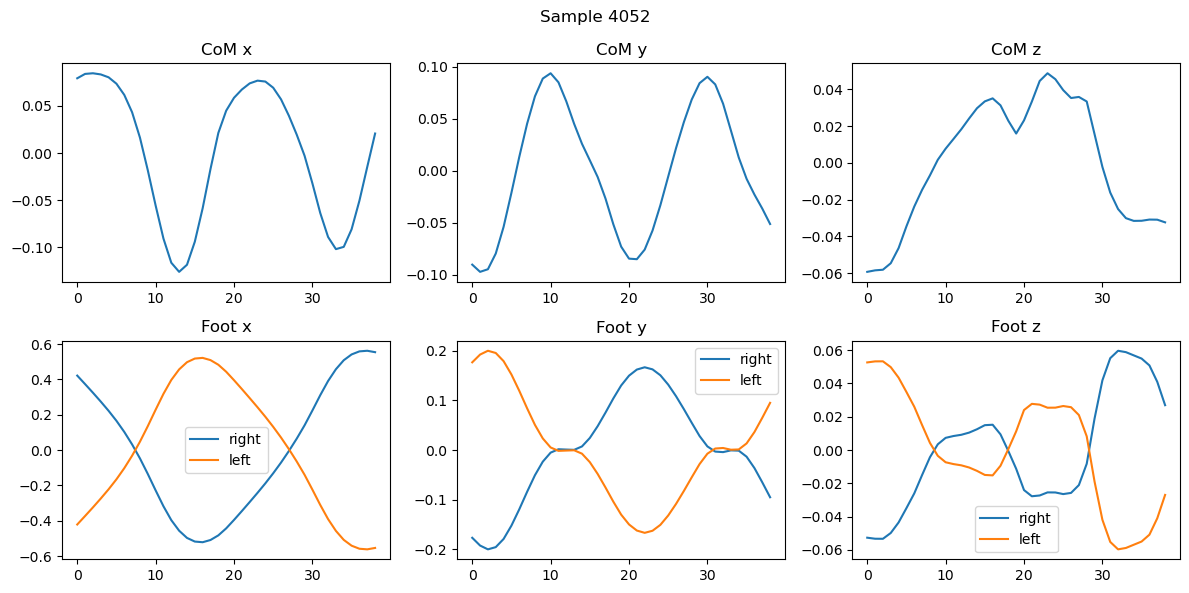

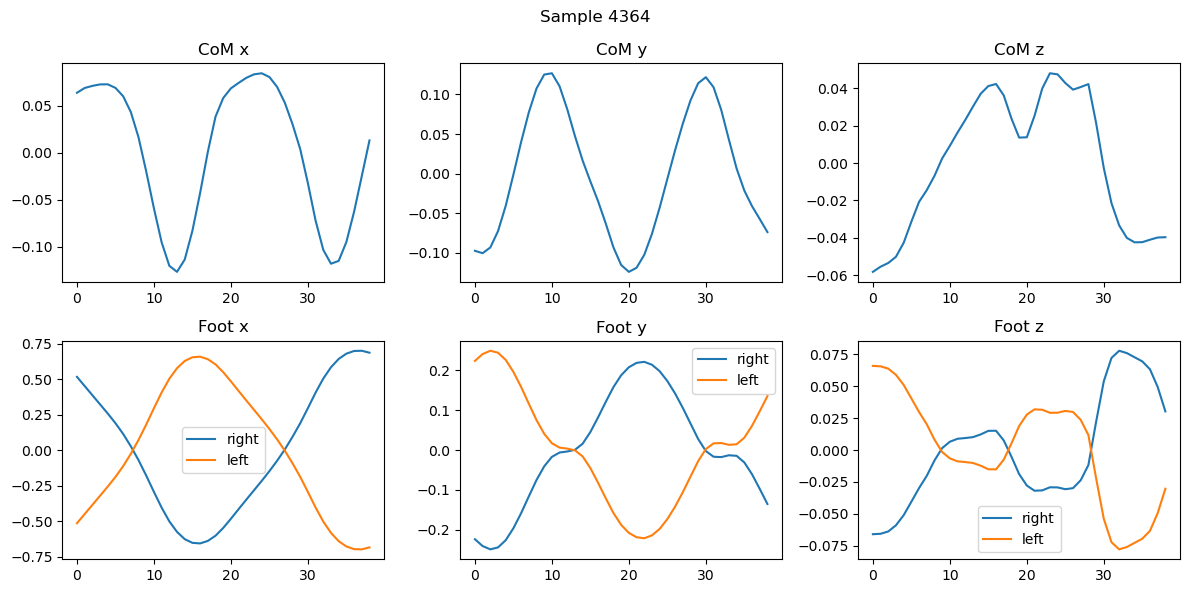

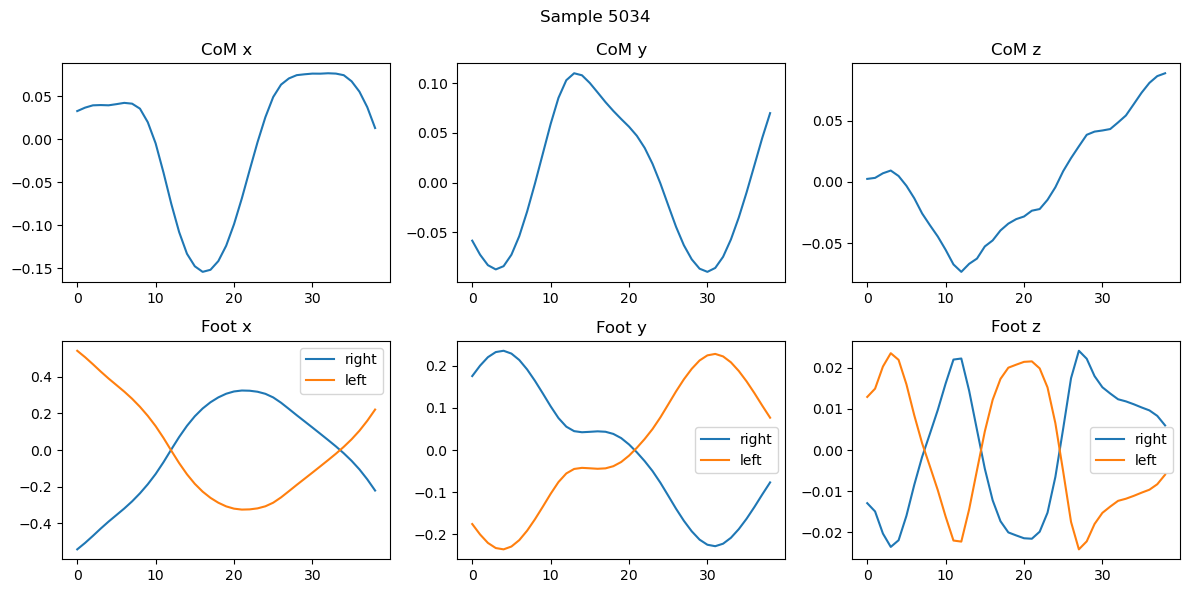

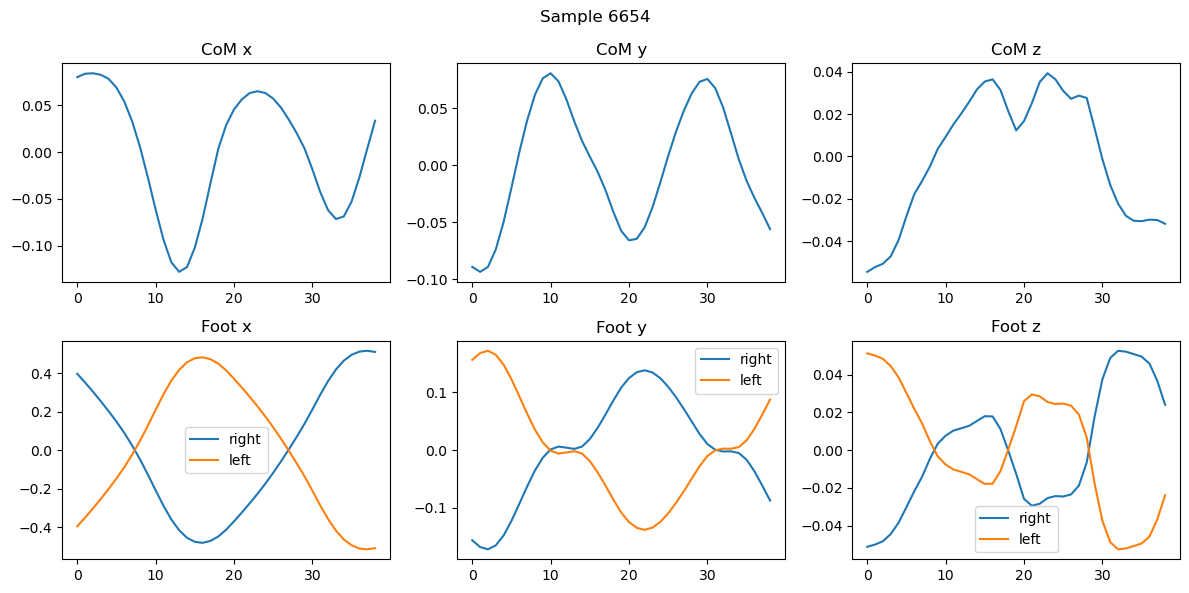

In [20]:
for i in range(5):
    idx = out_indices[i]
    plot_outlier_sequence(foot_train[idx], com_train[idx], idx)

these outliers look like people running, not like artifacts. Keep them and increase tail bound.

In [12]:
tail_bound = compute_tail_bound(train_dataset, quantile=1, margin=1.2)

  theta abs-max:  mean=1.851, p99=3.364, p99.99=4.383
  → tail_bound = 5.786


In [13]:
T = train_dataset.dataset_foot[0].shape[0]
foot_input_size = T * 6

#### Tuning model hyperparameters

In [20]:
model = SplineFlowSummary(
        foot_input_size=foot_input_size,
        theta_dim=DIM_PCA_COM,
        condition_size=16,
        s_hidden=512,
        s_layers=4,
        f_hidden=256,
        f_blocks=24,
        num_bins=20,
        tail_bound=tail_bound,
).to("cuda")


In [1]:
from models.nsf import train_inn_cond

In [24]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
lr_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        torch.optim.Adam(model.parameters(), lr=1e-3),
        mode='min',
        factor=0.5,
        patience=10
    )


In [25]:
history = train_inn_cond(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    optim=optim,
    epochs=50, # original 50
    batch_size=250,
    lr_scheduler=lr_scheduler

)

Training:   2%|▏         | 1/50 [00:31<25:21, 31.05s/it, test_loss=12, train_loss=33.1]

Epoch 0 avg OOB rate: 0.0000


Training:   4%|▍         | 2/50 [01:03<25:23, 31.73s/it, test_loss=2.19, train_loss=5.5]

Epoch 1 avg OOB rate: 0.0000


Training:   6%|▌         | 3/50 [01:35<25:07, 32.07s/it, test_loss=-3.6, train_loss=-2.05]

...

Epoch 47 avg OOB rate: 0.0000


Training:  98%|█████████▊| 49/50 [26:20<00:32, 32.35s/it, test_loss=-14.5, train_loss=-14.7]

Epoch 48 avg OOB rate: 0.0000


Training: 100%|██████████| 50/50 [26:52<00:00, 32.24s/it, test_loss=-14.5, train_loss=-14.7]

Epoch 49 avg OOB rate: 0.0000


In [ ]:
# save model and training history
torch.save({
    'model_state_dict': model.state_dict(),
    'pca': pca,
    'theta_mean': theta_mean,
    'theta_std': theta_std,
    'train_history': history['train_loss'],
    'test_history': history['test_loss'],
    
}, "nsf_com_pca_model.pt")

In [14]:
import torch 
checkpoint = torch.load("nsf_com_pca_model.pt", map_location="cpu")


In [15]:
model = SplineFlowSummary(
        foot_input_size=foot_input_size,
        theta_dim=DIM_PCA_COM,
        condition_size=16,
        s_hidden=512,
        s_layers=4,
        f_hidden=256,
        f_blocks=24,
        num_bins=20,
        tail_bound=tail_bound,
).to("cpu")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

SplineFlowSummary(
  (summary): SummaryNetwork(
    (encoder): Sequential(
      (0): Linear(in_features=234, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=512, bias=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=512, bias=True)
      (7): ReLU()
      (8): Linear(in_features=512, out_features=512, bias=True)
      (9): ReLU()
      (10): Linear(in_features=512, out_features=16, bias=True)
    )
  )
  (flow): SplineFlow(
    (coupling_blocks): ModuleList(
      (0-23): 24 x SplineCouplingBlock(
        (param_net): Sequential(
          (0): Linear(in_features=21, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=305, bias=True)
        )
      )
    )
    (linear_blocks): ModuleList(
      (

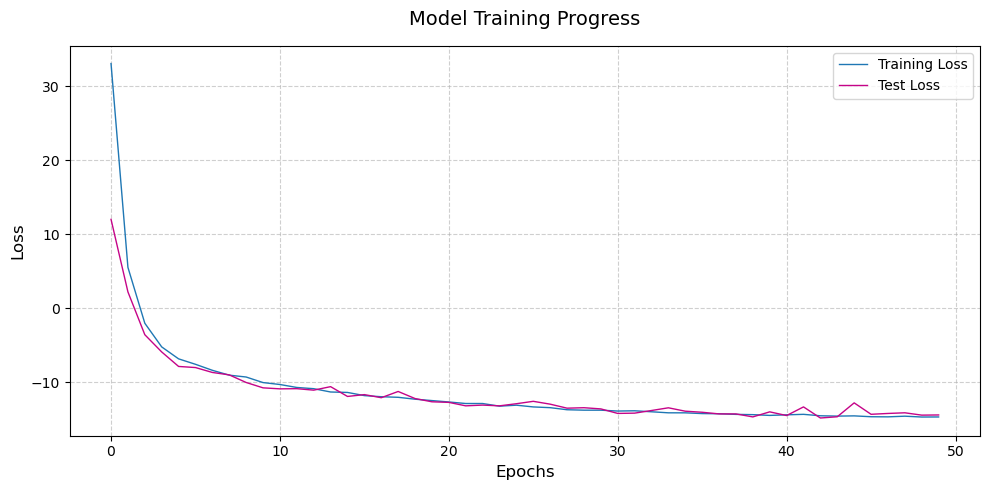

In [16]:
import matplotlib.pyplot as plt
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(checkpoint["train_history"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(checkpoint["test_history"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Analizar resultados


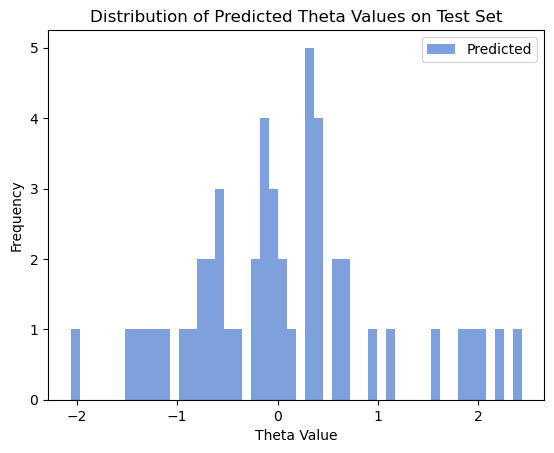

In [17]:
# calculate distribution of predicted theta values on test set, to check for outliers and tail coverage
test_theta_pred = []
for i in range(5):
    foot, theta_true = test_dataset[i]
    foot = foot.unsqueeze(0).to("cpu")  # (1, foot_input_size)
    
    with torch.no_grad():
        theta_pred = model.sample(foot, 100)  # (1, theta_dim)
    
    test_theta_pred.append(theta_pred.cpu().numpy()[0])
plt.hist(np.array(test_theta_pred).flatten(), bins=50, alpha=0.7, label='Predicted')
plt.title('Distribution of Predicted Theta Values on Test Set')
plt.xlabel('Theta Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()



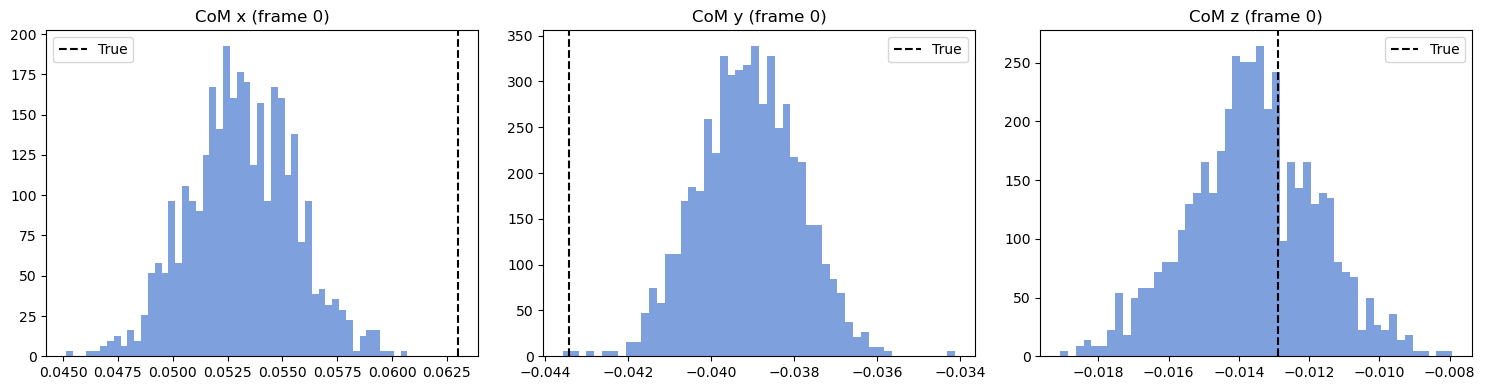

In [20]:
# Tomar una muestra del test set y muestrear la distribución de theta predicha por el modelo entrenado actual
idx = 5  # puedes cambiar el índice para ver diferentes muestras
foot_sample, theta_true = test_dataset[idx]
foot_sample = foot_sample.unsqueeze(0).to("cpu")  # (1, foot_input_size)
n_samples = 1000

with torch.no_grad():
    theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()  # (n_samples, theta_dim)

# Proyectar las muestras de theta de vuelta al espacio original de CoM usando el PCA entrenado
com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)  # (n_samples, T*3)
com_samples = com_samples.reshape(n_samples, -1, 3)  # (n_samples, T, 3)

# Tomar la trayectoria real de CoM para comparar
com_true = com_test[idx]  # (T, 3)

# Graficar la distribución de las primeras 3 dimensiones (x, y, z) del primer frame
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x (frame 0)", "CoM y (frame 0)", "CoM z (frame 0)"]
for d in range(3):
    axes[d].hist(com_samples[:, 0, d], bins=50, density=True, alpha=0.7)
    axes[d].axvline(com_true[0, d], linestyle="--", color="k", label="True")
    axes[d].set_title(labels[d])
    axes[d].legend()
plt.tight_layout()
plt.show()

In [ ]:
def run_experiment(config):

    # --- PCA
    pca, theta_mean, theta_std = fit_com_pca(
        com_train,
        theta_dim=config["pca_dim"]
    )

    # --- datasets
    train_dataset = FootComDataset(
        dataset_foot=foot_train,
        dataset_com=com_train,
        pca=pca,
        theta_mean=theta_mean,
        theta_std=theta_std,
    )

    test_dataset = FootComDataset(
        dataset_foot=foot_test,
        dataset_com=com_test,
        pca=pca,
        theta_mean=theta_mean,
        theta_std=theta_std,
    )

    # --- model
    model = SplineFlowSummary(
        foot_input_size=foot_input_size,
        theta_dim=config["pca_dim"],
        condition_size=config["condition_size"],
        s_hidden=config["s_hidden"],
        s_layers=config["s_layers"],
        f_hidden=config["f_hidden"],
        f_blocks=config["f_blocks"],
        num_bins=8,
        tail_bound=100.0,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = train_inn_cond(
        model=model,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        optim=optimizer,
        epochs=config["epochs"],
        batch_size=config["batch_size"]
    )

    val_loss = min(history["test_loss"])

    return val_loss, model, pca, theta_mean, theta_std, history

In [6]:
def save_best(model, config, pca, theta_mean, theta_std, val_loss, history, name):
    torch.save({
        "model_state": model.state_dict(),
        "config": config,
        "pca": pca,
        "theta_mean": theta_mean,
        "theta_std": theta_std,
        "val_loss": val_loss,
    }, f"best_{name}.pt")

### PCA DIMENSION

In [ ]:
base_config = {
    "pca_dim": 8,
    "f_blocks": 3,
    "f_hidden": 256,
    "s_hidden": 512,
    "s_layers": 4,
    "condition_size": 16,
    **FAST_TRAIN
}

pca_values = [5, 8, 10, 12]

best_loss = float("inf")
best_config = None

for d in pca_values:
    config = base_config.copy()
    config["pca_dim"] = d

    print(f"\nPCA dim = {d}")

    val_loss, model, pca, mean, std, history = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, history, "pca")

print("Best PCA:", best_config["pca_dim"])


PCA dim = 5


Training: 100%|██████████| 30/30 [03:02<00:00,  6.10s/it, test_loss=-7.22, train_loss=-6.77]



PCA dim = 8


Training: 100%|██████████| 30/30 [03:04<00:00,  6.16s/it, test_loss=-10.3, train_loss=-10.5]



PCA dim = 10


Training: 100%|██████████| 30/30 [03:01<00:00,  6.07s/it, test_loss=-9.85, train_loss=-10.6]



PCA dim = 12


Training: 100%|██████████| 30/30 [03:03<00:00,  6.10s/it, test_loss=-10.5, train_loss=-10]  

Best PCA: 10


### Summary network

In [93]:
summary_grid = [
    {"s_hidden": 256, "condition_size": 16},
    {"s_hidden": 512, "condition_size": 16},
    {"s_hidden": 512, "condition_size": 32},
]

best_loss = float("inf")

for params in summary_grid:
    config = best_config.copy()
    config.update(params)

    print(f"\nSummary params: {params}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "summary")


Summary params: {'s_hidden': 256, 'condition_size': 16}


Training: 100%|██████████| 30/30 [03:01<00:00,  6.03s/it, test_loss=-7.85, train_loss=-8.29]



Summary params: {'s_hidden': 512, 'condition_size': 16}


Training: 100%|██████████| 30/30 [02:59<00:00,  6.00s/it, test_loss=-9.2, train_loss=-9.97] 



Summary params: {'s_hidden': 512, 'condition_size': 32}


Training: 100%|██████████| 30/30 [03:00<00:00,  6.00s/it, test_loss=-10.2, train_loss=-10.4]


Neural spline flow network

In [101]:
flow_grid = [
    {"f_blocks": 3, "f_hidden": 256},
    {"f_blocks": 5, "f_hidden": 256},
    {"f_blocks": 5, "f_hidden": 512},
]

best_loss = float("inf")

for params in flow_grid:
    config = best_config.copy()
    config.update(params)

    print(f"\nFlow params: {params}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "flow")


Flow params: {'f_blocks': 3, 'f_hidden': 256}


Training: 100%|██████████| 30/30 [03:00<00:00,  6.01s/it, test_loss=-8.52, train_loss=-6.7]  



Flow params: {'f_blocks': 5, 'f_hidden': 256}


Training:   0%|          | 0/30 [00:00<?, ?it/s]


InputOutsideDomain: 

In [2]:
import torch
from torch import device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = ["best_pca.pt", "best_summary.pt", "best_flow.pt"]

results = []

for f in files:
    ckpt = torch.load(f, map_location=device)
    results.append((f, ckpt["val_loss"], ckpt["config"]))

# sort by loss
results.sort(key=lambda x: x[1])

for f, loss, config in results:
    print(f"\nFile: {f}")
    print(f"Val loss: {loss:.4f}")
    print("Config:", config)


File: best_pca.pt
Val loss: -11.0265
Config: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 16, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}

File: best_summary.pt
Val loss: -10.4645
Config: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 32, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}

File: best_flow.pt
Val loss: -8.5190
Config: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 32, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}


BEST HYPERPARAMETERS MODEL: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 16, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}

In [ ]:
base_config = {
    "pca_dim": 10,
    "f_blocks": 3,
    "f_hidden": 256,
    "s_hidden": 512,
    "s_layers": 4,
    "condition_size": 16,
    "epochs": 200,
    "batch_size": 256,
    "lr": 1e-3
}

batch_size = [32, 64, 128, 256]

best_loss = float("inf")
best_config = None

for d in batch_size:
    config = base_config.copy()
    config["batch_size"] = d

    print(f"\nBatch size = {d}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "pca")

print("Best batch size:", best_config["batch_size"])

In [ ]:
learningrate = [1e-4, 5e-4, 1e-3, 5e-3]

best_loss = float("inf")
best_config = None

for lr in learningrate:
    config = base_config.copy()
    config["lr"] = lr

    print(f"\nLearning rate = {lr}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "pca")

print("Best learning rate:", best_config["lr"])

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

file = torch.load("best_pca.pt", map_location=device)
loss = file["val_loss"]
print(f"Val loss: {loss:.4f}")


Val loss: -11.0265


In [ ]:
import matplotlib.pyplot as plt
model.to(device)
model.eval()
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(loss_history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(loss_history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()